In [3]:
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_eog=False,
)

desc_add = "clean-with-fd-clamped-original-sleep"


In [1]:
from pathlib import Path
from scipy.stats import spearmanr
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from tqdm.auto import trange
import numpy as np
import gdist
from nilearn.surface import load_surf_mesh, vol_to_surf, load_surf_data
from nilearn import datasets, plotting
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mreyemove.plotting.glm import custom_cmap
from nilearn.plotting.surface._matplotlib_backend import (
    _plot_surf,
    _get_ticks,
    _colorbar_from_array,
)
from nilearn.plotting.surface._utils import check_surface_plotting_inputs


def geodesic_neighborhoods_gdist(coords, faces, radius_mm=10.0):
    """
    Compute exact geodesic neighborhoods using the MMP algorithm (tvb-gdist).
    Accurate but slow for large meshes (e.g. fsaverage7).
    """
    dist_matrix = gdist.local_gdist_matrix(
        coords.astype(np.float64),
        faces.astype(np.int32),
        max_distance=radius_mm,
    )
    neighborhoods = dist_matrix.tolil()
    return [np.array(neighborhoods.rows[i]) for i in range(len(coords))]


def geodesic_neighborhoods(coords, faces, radius_mm=9.0, chunk_size=500):
    """
    Approximate geodesic neighborhoods using Dijkstra shortest paths
    on the mesh edge graph (Chen et al., 2011).
    Returns an array of shape (n,) where each entry i is an array 
    of indices less than radius_mm away from vertex i in the graph 
    """
    n = len(coords)
    # faces = faces.astype(np.int32)

    # Build weighted adjacency graph from mesh edges (vectorized)
    
    # Extract triangle vertices (from faces) to construct a list of pairwise edges
    edges = np.vstack([faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [0, 2]]])
    
    # Compute norm (magnitude) of distance between edges
    dists = np.linalg.norm(coords[edges[:, 0]] - coords[edges[:, 1]], axis=1)
    
    # Construct graph, edges in both directions
    graph = csr_matrix(
        (np.concatenate([dists, dists]),
         (np.concatenate([edges[:, 0], edges[:, 1]]),
          np.concatenate([edges[:, 1], edges[:, 0]]))),
        shape=(n, n),
    )

    # Chunked Dijkstra with distance cutoff
    neighborhoods = [None] * n
    for start in trange(0, n, chunk_size, desc="Dijkstra neighborhoods"):
        end = min(start + chunk_size, n)
        dist_chunk = dijkstra(
            graph, directed=False,
            indices=np.arange(start, end),
            limit=radius_mm,
        )
        for local_i in range(end - start):
            # Collect indices where distances are not None (and therefore lower than radius_mm)
            neighborhoods[start + local_i] = np.where(np.isfinite(dist_chunk[local_i]))[0]

    return neighborhoods


def surface_searchlight_correlation(
    map_a_surf: np.ndarray,
    map_b_surf: np.ndarray,
    coords: np.ndarray,
    faces: np.ndarray,
    radius_mm: float = 10.0,
    min_vertices: int = 10,
) -> np.ndarray:
    """
    Compute searchlight Pearson correlation between two surface maps
    using geodesic neighborhoods (Dijkstra on mesh graph).
    """
    print(f"Building geodesic neighborhoods (radius={radius_mm}mm)...")
    neighborhoods = geodesic_neighborhoods(coords, faces, radius_mm=radius_mm)

    neighbor_counts = np.array([len(n) for n in neighborhoods])
    print(f"Neighbors — Mean: {neighbor_counts.mean():.0f}, "
          f"Median: {np.median(neighbor_counts):.0f}, "
          f"Min: {neighbor_counts.min()}, Max: {neighbor_counts.max()}")

    corr_map = np.zeros(len(coords), dtype=np.float32)
    for i, nbrs in enumerate(neighborhoods):
        if len(nbrs) < min_vertices:
            continue
        a = map_a_surf[nbrs]
        b = map_b_surf[nbrs]
        if a.std() == 0 or b.std() == 0:
            continue
        corr_map[i] = spearmanr(a, b).statistic
    return corr_map


def run_fsaverage_surface_searchlight_correlation(
    vol_a,
    vol_b,
    surf_mesh: str ="fsaverage7",
    radius_mm=10.0,
    min_vertices=10,
):
    """
    Project two volume stat maps to surface and compute searchlight
    correlation for both hemispheres using geodesic neighborhoods.
    """
    fsaverage = datasets.fetch_surf_fsaverage(mesh=surf_mesh)

    results = {}
    for hemi, pial_key in [("left", "pial_left"), ("right", "pial_right")]:
        coords, faces = load_surf_mesh(fsaverage[pial_key])

        surf_a = vol_to_surf(vol_a, fsaverage[pial_key], interpolation="linear")
        surf_b = vol_to_surf(vol_b, fsaverage[pial_key], interpolation="linear")

        results[hemi] = surface_searchlight_correlation(
            surf_a, surf_b, coords, faces,
            radius_mm=radius_mm, min_vertices=min_vertices,
        )

    return results, fsaverage


def plot_surface_searchlight(
    corr_maps,
    surf_mesh="fsaverage7",
    cmap=None,
    vmin=-1,
    vmax=1,
    threshold=None,
    symmetric_cbar="auto",
    cbar_tick_format="%.1f",
    title=None,
    inflate=False,
    output_file=None,
    bg_on_data=True,
):
    """
    Plot surface searchlight correlation maps using the same rendering
    pipeline as glm_surface.py (internal _plot_surf).
    """
    if cmap is None:
        cmap = custom_cmap()

    fsaverage = datasets.fetch_surf_fsaverage(mesh=surf_mesh)
    hemis = ["left", "right"]
    modes = ["lateral", "medial"]

    if symmetric_cbar is None:
        symmetric_cbar = "auto"
    if cbar_tick_format is None:
        cbar_tick_format = "%i"

    cbar_h = 0.25
    title_h = 0.25 * (title is not None)
    w, h = plt.figaspect((1 + cbar_h + title_h) / (len(hemis) + len(modes)))
    fig = plt.figure(figsize=(w * 2, h * 2), constrained_layout=False)
    height_ratios = [title_h] + [1.0] + [cbar_h]
    grid = GridSpec(
        nrows=3,
        ncols=len(modes) + len(hemis),
        left=0.0,
        right=1.0,
        bottom=0.0,
        top=1.0,
        height_ratios=height_ratios,
        hspace=0.0,
        wspace=0.0,
    )
    axes = []

    panels = [
        ("left", "lateral"),
        ("right", "lateral"),
        ("right", "medial"),
        ("left", "medial"),
    ]
    mesh_prefix = "infl" if inflate else "pial"
    surf = {
        "left": fsaverage[f"{mesh_prefix}_left"],
        "right": fsaverage[f"{mesh_prefix}_right"],
    }

    for i, (hemi, mode) in enumerate(panels):
        if inflate:
            curv_map = load_surf_data(fsaverage[f"curv_{hemi}"])
            curv_sign_map = (np.sign(curv_map) + 1) / 4 + 0.25
            bg_map = curv_sign_map
        else:
            sulc_map = fsaverage[f"sulc_{hemi}"]
            bg_map = sulc_map        
        
        grid_idx = i + (len(hemis) + len(modes))

        ax = fig.add_subplot(grid[grid_idx], projection="3d")
        axes.append(ax)

        _plot_surf(
            surf_mesh=surf[hemi],
            surf_map=corr_maps[hemi],
            bg_map=bg_map,
            hemi=hemi,
            view=mode,
            cmap=cmap,
            darkness=None,
            colorbar=False,
            threshold=threshold,
            bg_on_data=bg_on_data,
            vmin=vmin,
            vmax=vmax,
            axes=ax,
        )
        ax.set_box_aspect(None, zoom=1.3)

    # Colorbar
    sm = _colorbar_from_array(
        np.concatenate([corr_maps["left"], corr_maps["right"]]),
        vmin, vmax, threshold,
        symmetric_cbar=symmetric_cbar,
        cmap=plt.get_cmap(cmap) if isinstance(cmap, str) else cmap,
    )
    cbar_grid = GridSpecFromSubplotSpec(3, 3, grid[-1, :])
    cbar_ax = fig.add_subplot(cbar_grid[1])
    ticks = _get_ticks(vmin, vmax, cbar_tick_format, threshold)
    fig.colorbar(
        sm, cax=cbar_ax, orientation="horizontal",
        ticks=ticks, format=cbar_tick_format,
    )

    if title is not None:
        fig.suptitle(title, y=1.0 - title_h / sum(height_ratios), va="bottom")

    if output_file:
        fig.savefig(str(output_file), dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

    return fig

/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_43648/1089918758.py:20: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_43648/1089918758.py:20: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(


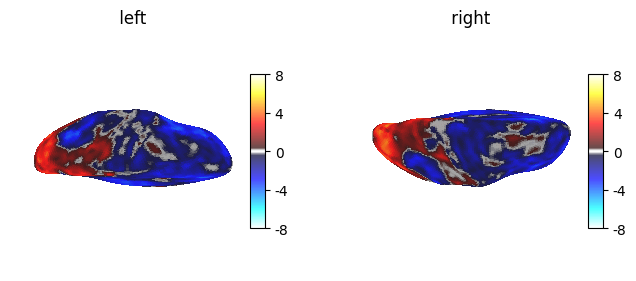

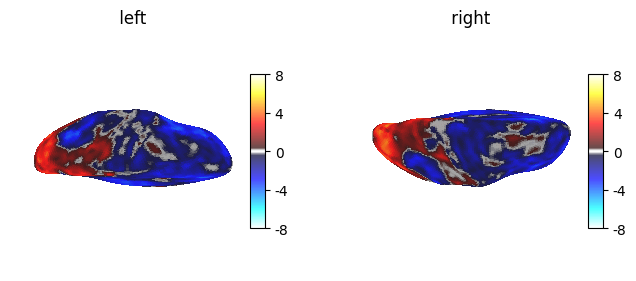

In [12]:
data_a, _ = mrio.load_FLAME_result(contrast="mreyemove_S", desc_add=desc_add)
import nibabel as nib
from nilearn import plotting, surface

# Load your tmap
tmap = data_a.t_stat

# Fetch fsaverage surface
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')  # or fsaverage7 for higher res

def plot_dorsal(tmap, threshold=2.3, vmax=8, cmap='cold_hot', title=''):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), 
                              subplot_kw={'projection': '3d'})
    
    for ax, hemi in zip(axes, ['left', 'right']):
        texture = surface.vol_to_surf(
            tmap,
            fsaverage[f'pial_{hemi}'],
        )
        plotting.plot_surf_stat_map(
            fsaverage[f'infl_{hemi}'],
            texture,
            hemi=hemi,
            view='dorsal',
            # threshold=threshold,
            vmin=-vmax,
            vmax=vmax,
            cmap=custom_cmap(),
            colorbar=True,
            axes=ax,
            title=f'{title} {hemi}'
        )
    
    return fig
plot_dorsal(tmap)


=== mreyemove_W vs mreyemove_S ===
(53, 65, 43)


TypeError: Cannot slice image objects; consider using `img.slicer[slice]` to generate a sliced image (see documentation for caveats) or slicing image array data with `img.dataobj[slice]` or `img.get_fdata()[slice]`

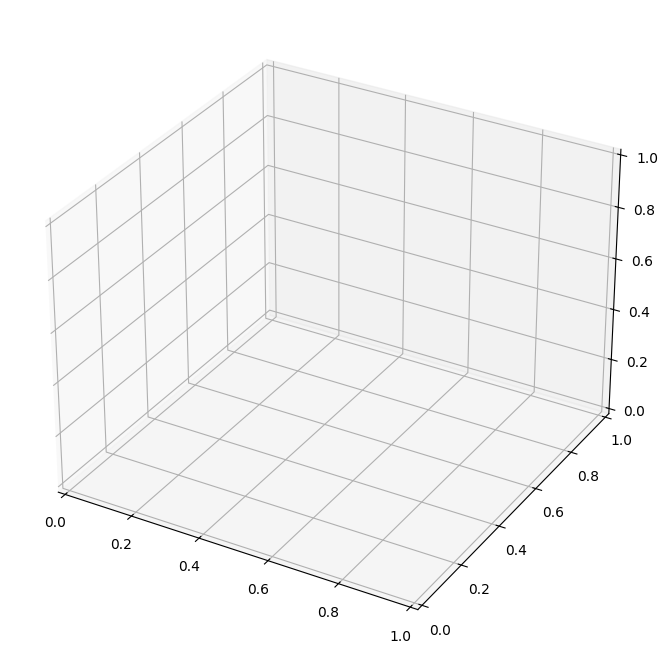

In [6]:
from mreyemove.plotting.glm import plot_img_on_surf_with_contour, custom_cmap

# --- Run searchlight and plot ---
desc_add = "clean-with-fd-clamped-original-sleep"
radius_mm = 19.0 * 2  # geodesic radius in mm
surf_mesh = "fsaverage7"
comparisons = [
    ("mreyemove_W", "mreyemove_S"),
    # ("mreyemove_1", "mreyemove_2"),
    # ("mreyemove_W", "mreyemove_1"),
    # ("mreyemove_W", "mreyemove_2"),
]

for contrast_a, contrast_b in comparisons:
    print(f"\n=== {contrast_a} vs {contrast_b} ===")

    data_a, _ = mrio.load_FLAME_result(contrast=contrast_a, desc_add=desc_add)
    data_b, _ = mrio.load_FLAME_result(contrast=contrast_b, desc_add=desc_add)
    
    print(data_a.t_stat.shape)

    corr_maps, _ = run_fsaverage_surface_searchlight_correlation(
        data_b.t_stat, data_a.t_stat,
        surf_mesh=surf_mesh,
        radius_mm=radius_mm,
    )

    for hemi in ("left", "right"):
        c = corr_maps[hemi]
        mask = np.abs(c) > 1e-6
        print(f"  {hemi}: mean r={c[mask].mean():.3f}, "
              f">0.3: {(c > 0.3).sum()}, "
              f"<-0.3: {(c < -0.3).sum()}")

    plot_surface_searchlight(
        corr_maps,
        surf_mesh=surf_mesh,
        inflate=True,
        title=f"Searchlight r: {contrast_a} vs {contrast_b} ({radius_mm}mm geodesic)",
        # threshold=0.3,
    )

In [0]:
fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage5")

coords, faces = load_surf_mesh(fsaverage["pial_left"])
nbrs_gdist = geodesic_neighborhoods_gdist(coords, faces, radius_mm=24.0)
nbrs_dijkstra = geodesic_neighborhoods(coords, faces, radius_mm=24.0)

overlaps = [len(set(a) & set(b)) / len(set(a) | set(b))
          for a, b in zip(nbrs_gdist, nbrs_dijkstra)]
print(f"Mean Jaccard overlap: {np.mean(overlaps):.3f}")
print(f"Mean gdist size: {np.mean([len(n) for n in nbrs_gdist]):.0f}")
print(f"Mean dijkstra size: {np.mean([len(n) for n in nbrs_dijkstra]):.0f}")


/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/PIAL_FSL.surf.gii
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/WHITE_FSL.surf.gii
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/PIAL_FSL.surf.gii
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/WHITE_FSL.surf.gii
Building geodesic neighborhoods (radius=38.0mm)...


Dijkstra neighborhoods:   0%|          | 0/58 [00:00<?, ?it/s]

Neighbors — Mean: 1389, Median: 1426, Min: 1, Max: 2326


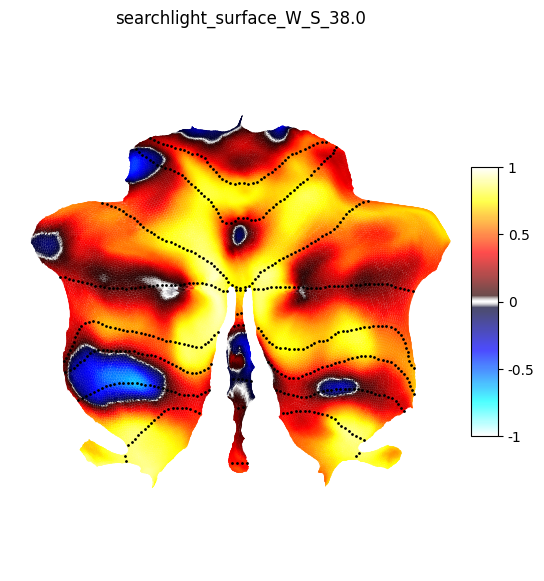

In [109]:
from mreyemove.analysis.glm.cli import construct_desc
import os
import nibabel as nib 
from SUITPy import flatmap

config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original.yml")
desc_add = construct_desc(dataset=mrio, config=config)
output_dir = Path('/Users/zach/2025_RA/matthias/final images/group_level/cerebellum/')

state_1 = "W"
state_2 = "S"
radius_mm = 38.0
title = f"searchlight_surface_{state_1}_{state_2}_{radius_mm}"
surf_path = os.path.join(flatmap._base_dir,'surfaces', f'PIAL_FSL.surf.gii')
coords, faces = load_surf_mesh(surf_path)

vol_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove_W", desc_add=desc_add)
vol_b,_ = mrio.load_FLAME_result(contrast=f"mreyemove_S", desc_add=desc_add)


surf_a = flatmap.vol_to_surf(vol_a.t_stat, space='FSL')
surf_b = flatmap.vol_to_surf(vol_b.t_stat, space='FSL')

results = surface_searchlight_correlation(
    map_a_surf=surf_a,
    map_b_surf=surf_b,
    coords=coords,
    faces=faces,
    radius_mm=radius_mm,
    min_vertices=10,
)

ax = flatmap.plot(data=results, cmap=custom_cmap(), 
        new_figure=True, 
        colorbar=True, 
        render='matplotlib',
        cscale=[-1.0, 1.0])
ax.set_title(title)

output_path = output_dir / f"{title}.png"

ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")

<Axes: >

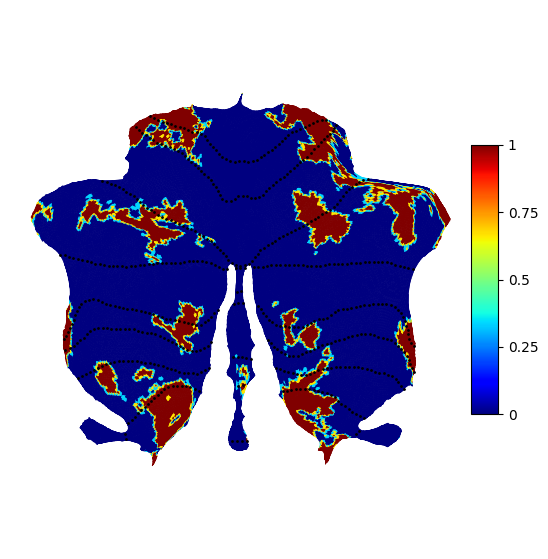

In [88]:
# Find vertices where wake is negative and sleep is positive (or vice versa)
sign_flip = (surf_a < 0) & (surf_b > 0)
candidates = np.where(sign_flip)[0]

# Plot them on the flatmap to see which ones are in the nub
flip_map = np.zeros_like(results)
flip_map[candidates] = 1
flatmap.plot(data=flip_map, new_figure=True, colorbar=True, render='matplotlib')

Dijkstra neighborhoods:   0%|          | 0/58 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Vertex 13300, r=0.276')

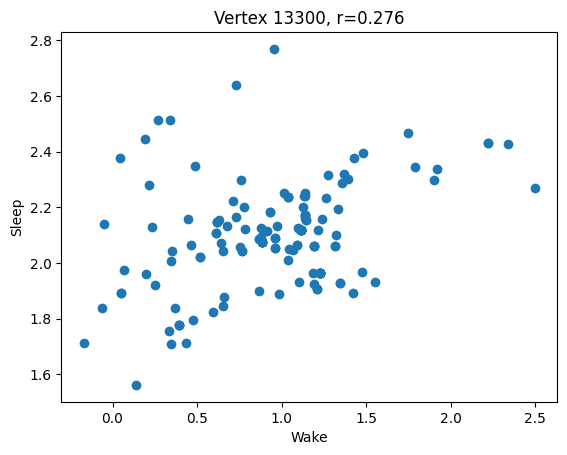

In [87]:
nbrs = geodesic_neighborhoods(coords, faces, radius_mm=18)
v = 13300
a = surf_a[nbrs[v]]
b = surf_b[nbrs[v]]
plt.scatter(a, b)
plt.xlabel("Wake"); plt.ylabel("Sleep")
plt.title(f"Vertex {v}, r={spearmanr(a,b).statistic:.3f}")


Dijkstra neighborhoods:   0%|          | 0/58 [00:00<?, ?it/s]

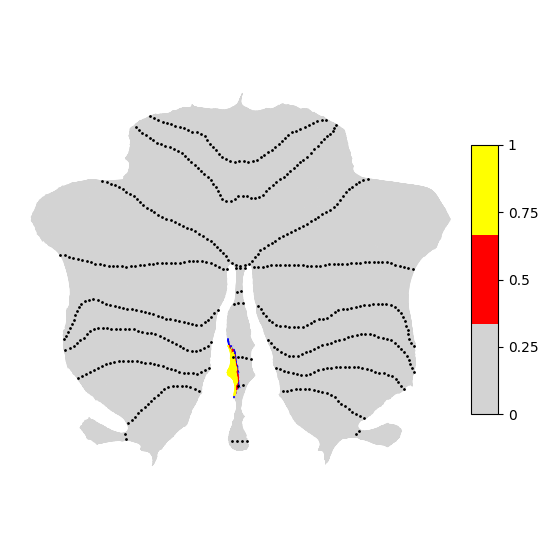

In [86]:
n_map = np.zeros_like(results)

center_vertex = 13300
radius_mm = 9
nbrs_dijkstra = geodesic_neighborhoods(coords, faces, radius_mm=radius_mm*2)
dset = set(nbrs_dijkstra[center_vertex])

for v in dset:
    n_map[v] = 1  # gdist only


from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgray", "blue", "red", "yellow"])

ax = flatmap.plot(data=n_map, cmap=cmap, 
        new_figure=True, 
        colorbar=True, 
        render='matplotlib')


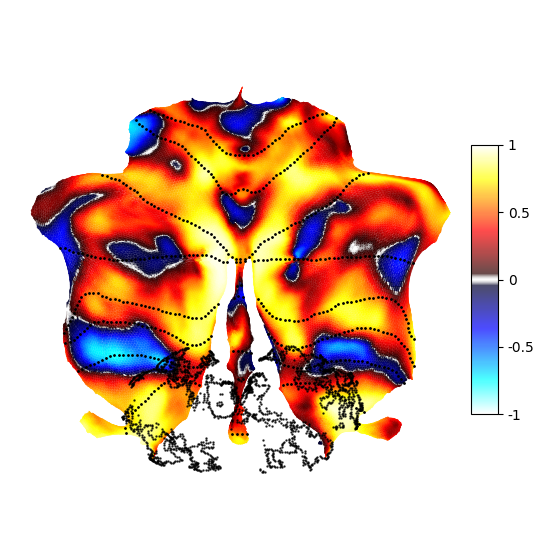

In [95]:

ax = flatmap.plot(data=results, cmap=custom_cmap(), 
        new_figure=True, 
        colorbar=True, 
        render='matplotlib',
        cscale=[-1.0, 1.0])

surf_path = os.path.join(flatmap._base_dir,'surfaces', f'PIAL_FSL.surf.gii')

flat_surf = nib.load(surf_path)
flat_coords = flat_surf.darrays[0].data  # 2D vertex positions
flat_faces = flat_surf.darrays[1].data.reshape(-1, 3)
# Find sign-flip boundary vertices: sign-flip vertices that neighbor non-sign-flip vertices
sign_flip = ((surf_a < 0) & (surf_b > 0)).ravel()
border = []
for f in flat_faces:
  vals = sign_flip[f]
  if vals.any() and not vals.all():  # face straddles boundary
      border.extend(f[vals])

border = np.unique(border)

# Overlay boundary on the flatmap
ax.scatter(flat_coords[border, 0], flat_coords[border, 1],
         s=0.5, c='black', alpha=0.8, zorder=5)


In [0]:
import os
import nibabel as nib 
from SUITPy import flatmap

surf_mesh = nib.load(os.path.join(flatmap._base_dir,'surfaces', f'PIAL_FSL.surf.gii'))
mreyemove_group_1,_ = mrio.load_FLAME_result(contrast=f"mreyemove_W", desc_add=desc_add)
mreyemove_group_2,_ = mrio.load_FLAME_result(contrast=f"mreyemove_S", desc_add=desc_add)

print(data_a.t_stat.shape)

corr_maps, _ = run_fsaverage_surface_searchlight_correlation(
    mreyemove_group_1.t_stat, mreyemove_group_2.t_stat,
    surf_mesh=surf_mesh,
    radius_mm=radius_mm,
)

for hemi in ("left", "right"):
    c = corr_maps[hemi]
    mask = np.abs(c) > 1e-6
    print(f"  {hemi}: mean r={c[mask].mean():.3f}, "
          f">0.3: {(c > 0.3).sum()}, "
          f"<-0.3: {(c < -0.3).sum()}")

plot_surface_searchlight(
    corr_maps,
    surf_mesh=surf_mesh,
    inflate=True,
    title=f"Searchlight r: {contrast_a} vs {contrast_b} ({radius_mm}mm geodesic)",
    # threshold=0.3,
)


In [66]:
# Visualise a single searchlight neighborhood on the surface
fsaverage7 = datasets.fetch_surf_fsaverage(mesh="fsaverage7")
coords7, faces7 = load_surf_mesh(fsaverage7["pial_left"])

center_vertex = 5000
radius_mm = 9.0

# Compute neighborhoods using both methods
nbrs_dijkstra = geodesic_neighborhoods(coords7, faces7, radius_mm=radius_mm*2)

fsaverage5 = datasets.fetch_surf_fsaverage(mesh="fsaverage5")
coords5, faces5 = load_surf_mesh(fsaverage5["pial_left"])
nbrs_gdist = geodesic_neighborhoods_gdist(coords5, faces5, radius_mm=radius_mm)

# Build maps: 1 = dijkstra only, 2 = gdist only, 3 = both
dset = set(nbrs_dijkstra[center_vertex])
gset = set(nbrs_gdist[center_vertex])
print(f"Dijkstra: {len(dset)} vertices, gdist: {len(gset)} vertices")
print(f"Overlap: {len(dset & gset)}, Jaccard: {len(dset & gset) / len(dset | gset):.3f}")


[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Dijkstra: 584 vertices, gdist: 46 vertices
Overlap: 36, Jaccard: 0.061


/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_80779/3621971635.py:12: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_80779/3621971635.py:34: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(


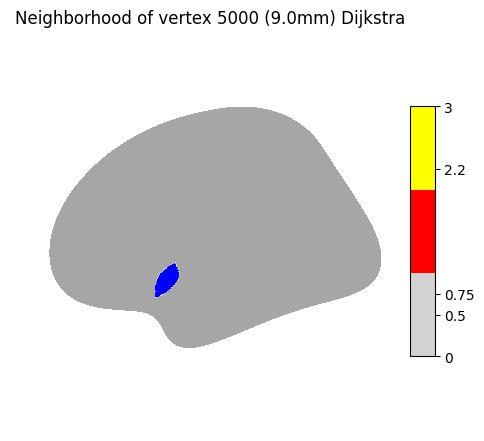

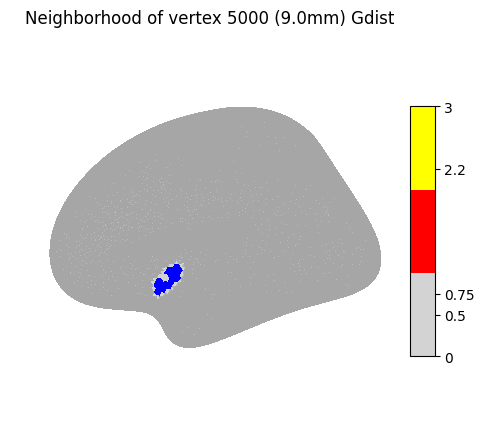

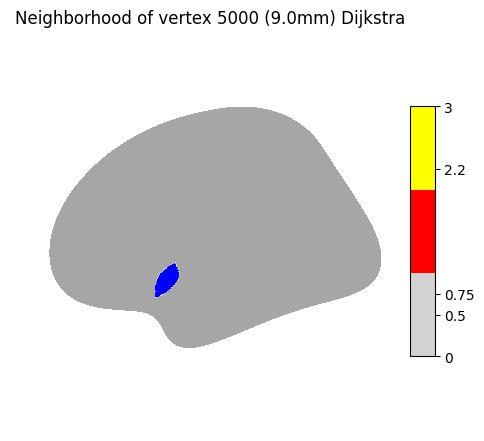

In [67]:

neighborhood_map = np.zeros(len(coords5))
# for v in dset:
#     neighborhood_map[v] = 1  # dijkstra only
for v in gset:
    neighborhood_map[v] = 1  # gdist only
# for v in dset & gset:
#     neighborhood_map[v] = 3  # both

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgray", "blue", "red", "yellow"])

plotting.plot_surf_stat_map(
    fsaverage5["infl_left"],
    neighborhood_map,
    hemi="left",
    view="lateral",
    cmap=cmap,
    threshold=0.5,
    vmin=0, vmax=3,
    title=f"Neighborhood of vertex {center_vertex} ({radius_mm}mm) Gdist",
)

neighborhood_map = np.zeros(len(coords7))
for v in dset:
    neighborhood_map[v] = 1  # dijkstra only
# for v in gset:
#     neighborhood_map[v] = 1  # gdist only
# for v in dset & gset:
#     neighborhood_map[v] = 3  # both

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgray", "blue", "red", "yellow"])

plotting.plot_surf_stat_map(
    fsaverage7["infl_left"],
    neighborhood_map,
    hemi="left",
    view="lateral",
    cmap=cmap,
    threshold=0.5,
    vmin=0, vmax=3,
    title=f"Neighborhood of vertex {center_vertex} ({radius_mm}mm) Dijkstra",
)

In [16]:
import gdist

center = 5000
coords5, faces5 = load_surf_mesh(fsaverage5["pial_left"])

# Get boundary vertices of the gdist neighborhood
nbrs_g = geodesic_neighborhoods_gdist(coords5, faces5, radius_mm=24.0)
nbr_set = set(nbrs_g[center])

# Find border vertices
adj = csr_matrix((np.ones(len(faces5)*6),
  (np.concatenate([faces5[:,0], faces5[:,1], faces5[:,1], faces5[:,2], faces5[:,0],
faces5[:,2]]),
   np.concatenate([faces5[:,1], faces5[:,0], faces5[:,2], faces5[:,1], faces5[:,2],
faces5[:,0]]))),
  shape=(len(coords5), len(coords5)))

border = [v for v in nbr_set if any(n not in nbr_set for n in adj[v].indices)]

# Compute exact geodesic distance from center to border vertices
dists = gdist.compute_gdist(
  coords5.astype(np.float64),
  faces5.astype(np.int32),
  source_indices=np.array([center], dtype=np.int32),
  target_indices=np.array(border, dtype=np.int32),
)
print(f"Border geodesic distances: mean={dists.mean():.1f}, min={dists.min():.1f}, max={dists.max():.1f}")


nbrs_d = geodesic_neighborhoods(coords5, faces5, radius_mm=24.0)
nbr_set_d = set(nbrs_d[center])

border_d = [v for v in nbr_set_d if any(n not in nbr_set_d for n in adj[v].indices)]

dists_d = gdist.compute_gdist(
  coords5.astype(np.float64),
  faces5.astype(np.int32),
  source_indices=np.array([center], dtype=np.int32),
  target_indices=np.array(border_d, dtype=np.int32),
)
print(f"Dijkstra border geodesic distances: mean={dists_d.mean():.1f}, min={dists_d.min():.1f}, max={dists_d.max():.1f}")

Border geodesic distances: mean=20.8, min=1.1, max=24.0


Dijkstra neighborhoods:   0%|          | 0/21 [00:00<?, ?it/s]

Dijkstra border geodesic distances: mean=9.1, min=5.9, max=11.8


In [100]:
from numpy.lib.stride_tricks import sliding_window_view
import numpy as np


def vec_pearson_corrcoef(X: np.array, Y: np.array, k):
    Sx  = X.sum(-1) 
    Sy  = Y.sum(-1)
    Sxx = (X * X).sum(-1)
    Syy = (Y * Y).sum(-1)
    Sxy = (X * Y).sum(-1)

    num = k*Sxy - Sx*Sy
    den = np.sqrt((k*Sxx - Sx*Sx) * (k*Syy - Sy*Sy))
    
    r = np.zeros_like(num, dtype=np.float32)
    np.divide(num, den, out=r, where=den!=0)
    return r



def sphere_mask(r):
    """
    Create a sphere of indices
    Uses mgrid to create a cube and then checks which 
    indices are less than the radius 
    Parameters
    ----------
    r

    Returns
    -------

    """
    z,y,x = np.mgrid[-r:r+1, -r:r+1, -r:r+1]
    return (x*x + y*y + z*z) <= r*r   # Assumes isotropic


def rolling_pearson_corr(A, B, radius):
    W = (2*radius+1,)*3  # window shape 
    sph = sphere_mask(radius)  # sphere mask within window              
    k = int(sph.sum())
    
    # Extract all all cube subsets and then mask with our sphere mask
    A_wind = sliding_window_view(A, W)[..., sph]
    B_wind = sliding_window_view(B, W)[..., sph]

    # Reshape sliding window views so that windows are 1D - more efficient 
    A_flat_wind = A_wind.reshape(-1, k)
    B_flat_wind = B_wind.reshape(-1, k)
    
    rho = vec_pearson_corrcoef(A_flat_wind, B_flat_wind, k)
    out_shape = tuple(d - 2*radius for d in A.shape)
    rho_valid = rho.reshape(out_shape)

    # Embed back into full-sized volume, padding AFTER the correlation
    out = np.full(A.shape, 0, dtype=np.float32)
    out[radius:-radius, radius:-radius, radius:-radius] = rho_valid

    return out


In [63]:
coords7, faces7 = load_surf_mesh(fsaverage7["pial_left"])
vertex_mm = coords7[5000]  # MNI coordinates of vertex 5000

vol = data_a.t_stat
inv_affine = np.linalg.inv(vol.affine)
voxel_ijk = np.round(inv_affine @ np.append(vertex_mm, 1))[:3].astype(int)
print(f"Vertex 5000 MNI: {vertex_mm}, voxel: {voxel_ijk}")

Vertex 5000 MNI: [-39.78633    -7.8668604  -4.841265 ], voxel: [13 35 18]


In [104]:
fsaverage7 = datasets.fetch_surf_fsaverage(mesh="fsaverage7")
coords7, faces7 = load_surf_mesh(fsaverage7["pial_left"])

center_vertex = 5000
radius_mm = 14.0

nbrs_dijkstra = geodesic_neighborhoods(coords7, faces7, radius_mm=radius_mm*2)

dset = set(nbrs_dijkstra[center_vertex])

[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_7410/2093291685.py:35: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(


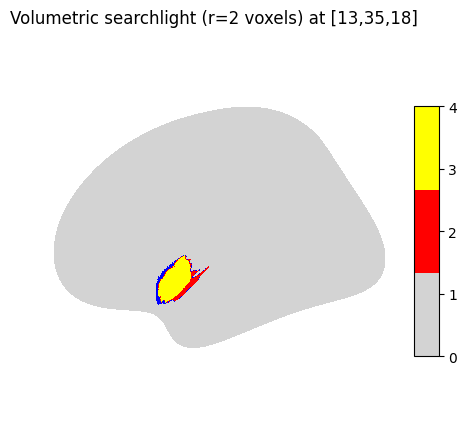

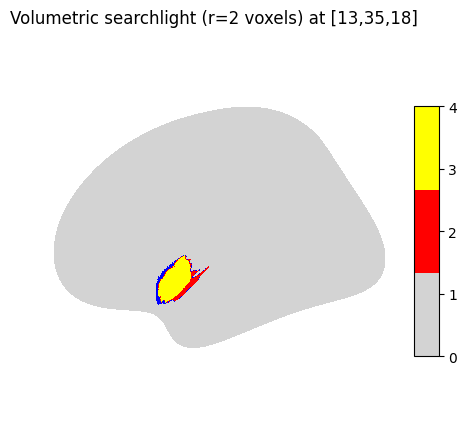

In [105]:
from nilearn.image import new_img_like
import nibabel as nib

# Load any volume for the affine/shape
data_a, _ = mrio.load_FLAME_result(contrast="mreyemove_W")
vol = data_a.t_stat
vol_data = vol.get_fdata()

# Pick a voxel near the center of the brain
cx, cy, cz = 13, 35, 18  # adjust as needed
radius = 2

sph = sphere_mask(radius)
neighborhood = np.zeros_like(vol_data)
r = radius
neighborhood[cx-r:cx+r+1, cy-r:cy+r+1, cz-r:cz+r+1][sph] = 1

neighborhood_img = new_img_like(vol, neighborhood)
neighbourhood_surf = vol_to_surf(neighborhood_img, fsaverage7["pial_left"])
vset = set(np.where(neighbourhood_surf > 0)[0])

neighborhood_map = np.zeros(len(coords7))
for v in dset:
    neighborhood_map[v] = 1  # dijkstra only
for v in vset:
    neighborhood_map[v] = 2  # volume only
for v in vset & dset:
    neighborhood_map[v] = 3  # both


from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgray", "blue", "red", "yellow"], N=4)

# from mreyemove.plotting.glm import plot_img_on_surf_with_contour
plotting.plot_surf_stat_map(
    surf_mesh=fsaverage7["infl_left"],
    stat_map=neighborhood_map,
    hemi="left",
    view="lateral",
    cmap=cmap,
    # threshold=0.5,
    vmin=0, vmax=4,
  # stat_map=neighborhood_img,
  # views=["lateral"],
  # hemispheres=["left"],
  # surf_mesh="fsaverage7",
  # cmap="Reds",
  # threshold=0.5,
  # inflate=True,
  title=f"Volumetric searchlight (r={radius} voxels) at [{cx},{cy},{cz}]",
)


In [106]:
intersection = vset & dset
union = vset | dset

print(f"r={radius_mm:5.1f}mm: "
      f"|dset|={len(dset):5d}, "
      f"|vset∩dset|={len(intersection):4d}/{len(vset):4d} ({100*len(intersection)/len(vset):.1f}% of vset), "
      f"Jaccard={len(intersection)/len(union):.3f}")

r= 14.0mm: |dset|= 1350, |vset∩dset|=1122/1476 (76.0% of vset), Jaccard=0.658


In [103]:
for radius_mm in [13, 15, 17, 19]:
    nbrs_dijkstra = geodesic_neighborhoods(coords7, faces7, radius_mm=radius_mm*2)
    dset = set(nbrs_dijkstra[center_vertex])
    
    intersection = vset & dset
    union = vset | dset
    
    print(f"r={radius_mm:5.1f}mm: "
          f"|dset|={len(dset):5d}, "
          f"|vset∩dset|={len(intersection):4d}/{len(vset):4d} ({100*len(intersection)/len(vset):.1f}% of vset), "
          f"Jaccard={len(intersection)/len(union):.3f}")

Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

r= 13.0mm: |dset|= 1182, |vset∩dset|=1023/1476 (69.3% of vset), Jaccard=0.626


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

r= 15.0mm: |dset|= 1524, |vset∩dset|=1190/1476 (80.6% of vset), Jaccard=0.657


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

r= 17.0mm: |dset|= 1897, |vset∩dset|=1279/1476 (86.7% of vset), Jaccard=0.611


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

r= 19.0mm: |dset|= 2315, |vset∩dset|=1352/1476 (91.6% of vset), Jaccard=0.554


In [ ]:
plot_surface_searchlight(
    corr_maps,
    title=f"Searchlight r: {contrast_a} vs {contrast_b} ({radius}mm)",
    threshold=0,
)